<!-- [md-intro] -->
# Why the August s01 desktop forecast starts *above* the actuals

**The question.** In `data-official/2026-08/plots/desktop_current_only.png`, the green forecast
28-day MA begins at the 2026-07-28 seam roughly 100K *above* where the black actuals 28-day MA
ends. Why?

**The answer, up front.** The step is **+102,595 DAU**, and none of it comes from the model.
The forecast itself is *continuous* across the seam — it is still falling, as the actuals were.
The step is manufactured by the plotting function `display_ma`, which rebuilds the first forecast
day's value ~5.9M too high. That single inflated day enters a 28-day trailing window as
`5,921,427 / 28 = +211,480` on the MA, which more than cancels the true `-108,884/day` decline:

```
  true trend at the seam (plain 28MA step)      -108,884
  display_ma's reconstruction error           +211,480
  ------------------------------------------------------
  published step                              +102,596      <-- what you see
```

**Root cause in one sentence.** `reconstruct_matched_daily` deseasonalizes the forecast with a
7-day *centered* mean computed on the forecast-only series; at the seam there are no days to the
left, so the "centered" window collapses to a forward-looking average of **Tue–Fri with the
weekend excluded**, overstating the deseasonalized trend by ~10% — and that inflated trend is
then multiplied by the Tuesday day-of-week factor (1.1448), compounding the error.

## How to read this notebook

Each rung establishes one link in the chain, with a plot. Nothing is asserted that isn't
measured in the cell above it.

| Rung | Establishes |
|---|---|
| 0 | The black and green curves share one data source, so the step is not a source mismatch |
| 1 | The raw daily forecast is continuous; only the *reconstructed* day-1 value spikes |
| 2 | Why it spikes: the centered-mean window at the seam has no weekend in it |
| 3 | How a one-day spike becomes a level step, in 7-day and 28-day MA space |
| 4 | The closing arithmetic |
| 5 | Falsification test: the step's sign should track the seam's weekday — does it? |

**Scope.** This is diagnosis only. No fix is proposed or applied here.


In [1]:
# [setup]
# Anchor at the git root so every relative path below resolves regardless of where
# this notebook is opened from.
import os
import subprocess
import sys

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

os.chdir(subprocess.run(["git", "rev-parse", "--show-toplevel"],
                        capture_output=True, text=True).stdout.strip())
sys.path.insert(0, "src")

# The functions under investigation live in June's canonical exporter. The August canonical
# notebook imports display_ma from exactly this path, so we are testing the shipped code, not
# a copy of it. (Flagged in data-official/2026-08 as a 2026-06 dependency to be re-homed.)
sys.path.insert(0, "data-official/2026-06")
from export_canonical_curves import display_ma, reconstruct_matched_daily  # noqa: E402

from mozaic_daily.adjustments import load_forecast  # noqa: E402

# --- What the published August desktop chart is built from ---
DESKTOP_FORECAST_PATH = (
    "data-official/2026-08/desktop_locked/"
    "mozaic_daily_forecast.2026-07-28.ld-D.adj-lo.parquet"
)
# Cached copy of the [bq-actuals] query from the August canonical notebook. Cached because that
# query scans ~93 GB; rung 0 proves it is redundant with the parquet's own training rows anyway.
ACTUALS_CACHE = "research/ma-seam-turbulence/extracts/desktop_actuals_2026-06-01_2026-07-27.csv"

SEAM = pd.Timestamp("2026-07-28")   # forecast_start: trained through 2026-07-27
WINDOW = 28                          # the display MA window
PLOTS_DIR = "research/ma-seam-turbulence/plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

DOW_NAMES = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.autolayout": True})


def millions(x, _pos=None):
    """Two decimals so adjacent ticks on a narrow range stay distinguishable (47.20M vs 47.32M)."""
    return f"{x / 1e6:.2f}M"


def thousands(x, _pos=None):
    return f"{x / 1e3:,.0f}K"


print(f"cwd:  {os.getcwd()}")
print(f"seam: {SEAM.date()} ({SEAM.day_name()})")


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureWarning)


cwd:  /Users/brendanwells/work/mozaic-daily
seam: 2026-07-28 (Tuesday)


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# [load-series]
# Load exactly what the published chart loads: the ALL-country / os=ALL / legacy_desktop row of
# the locked August desktop parquet. require_state pins the expected overlays (launch-on-login +
# MozillaOnline), so a mislabelled artifact fails loudly here rather than quietly changing the
# numbers this notebook reports.
desktop_df, desktop_meta = load_forecast(DESKTOP_FORECAST_PATH, require_state=["l", "o"])

row_mask = (
    (desktop_df["country"] == "ALL")
    & (desktop_df["segment"] == '{"os": "ALL"}')
    & (desktop_df["data_source"] == "legacy_desktop")
    & (desktop_df["app_name"] == "desktop")
)
desktop = desktop_df.loc[row_mask, ["target_date", "dau", "data_type"]].copy()
desktop["target_date"] = pd.to_datetime(desktop["target_date"])
desktop = desktop.sort_values("target_date").reset_index(drop=True)

# The single daily series the whole diagnosis rests on: training rows (actuals) then forecast rows.
daily = pd.Series(desktop["dau"].values, index=pd.DatetimeIndex(desktop["target_date"]))
is_training = pd.Series(desktop["data_type"].values == "training", index=daily.index)

last_training = daily.index[is_training].max()
assert last_training == SEAM - pd.Timedelta(days=1), (
    f"seam mismatch: last training day is {last_training.date()}, expected {(SEAM - pd.Timedelta(days=1)).date()}"
)

# Cached actuals, for the rung-0 cross-check only.
actuals = pd.read_csv(ACTUALS_CACHE, parse_dates=["date"]).set_index("date")["dau"].astype(float)

print(f"parquet:   {len(daily):,} days, {daily.index.min().date()} .. {daily.index.max().date()}")
print(f"training:  through {last_training.date()}  ({is_training.sum():,} days)")
print(f"forecast:  from {SEAM.date()}  ({(~is_training).sum():,} days)")
print(f"actuals cache: {len(actuals)} days, {actuals.index.min().date()} .. {actuals.index.max().date()}")
print()
print("Overlays baked into this parquet (from the sidecar meta):")
for adj in desktop_meta.get("adjustments_applied", []):
    print(f"  {adj['code']}  {adj.get('name', '')}")
print("\nNote: the Win10 headwind `h` is NOT in this list -- it is applied at the display layer.")
print("Its August spec ramps from start_date 2026-07-28 (the seam), so its value AT the seam is")
print("exactly 0. It therefore cannot contribute to the step. Verified in rung 4.")


parquet:   2,922 days, 2020-01-01 .. 2027-12-31
training:  through 2026-07-27  (2,400 days)
forecast:  from 2026-07-28  (522 days)
actuals cache: 57 days, 2026-06-01 .. 2026-07-27

Overlays baked into this parquet (from the sidecar meta):
  l  launch_on_login
  o  mozillaonline_migration

Note: the Win10 headwind `h` is NOT in this list -- it is applied at the display layer.
Its August spec ramps from start_date 2026-07-28 (the seam), so its value AT the seam is
exactly 0. It therefore cannot contribute to the step. Verified in rung 4.


Compared 57 overlapping days (2026-06-01 .. 2026-07-27)
max |parquet_training - bq_actuals| = 3 DAU (0.000006% of mean DAU)
mean signed difference             = +0.01 DAU

           bq_actuals parquet_training diff
2026-07-20 50,989,228       50,989,228   +0
2026-07-21 53,006,162       53,006,160   -2
2026-07-22 53,064,739       53,064,738   -1
2026-07-23 52,210,751       52,210,750   -1
2026-07-24 49,030,120       49,030,119   -1
2026-07-25 35,428,559       35,428,557   -2
2026-07-26 32,945,212       32,945,212   +0
2026-07-27 51,669,205       51,669,204   -1



saved: research/ma-seam-turbulence/plots/step_rung0_source_agreement.png


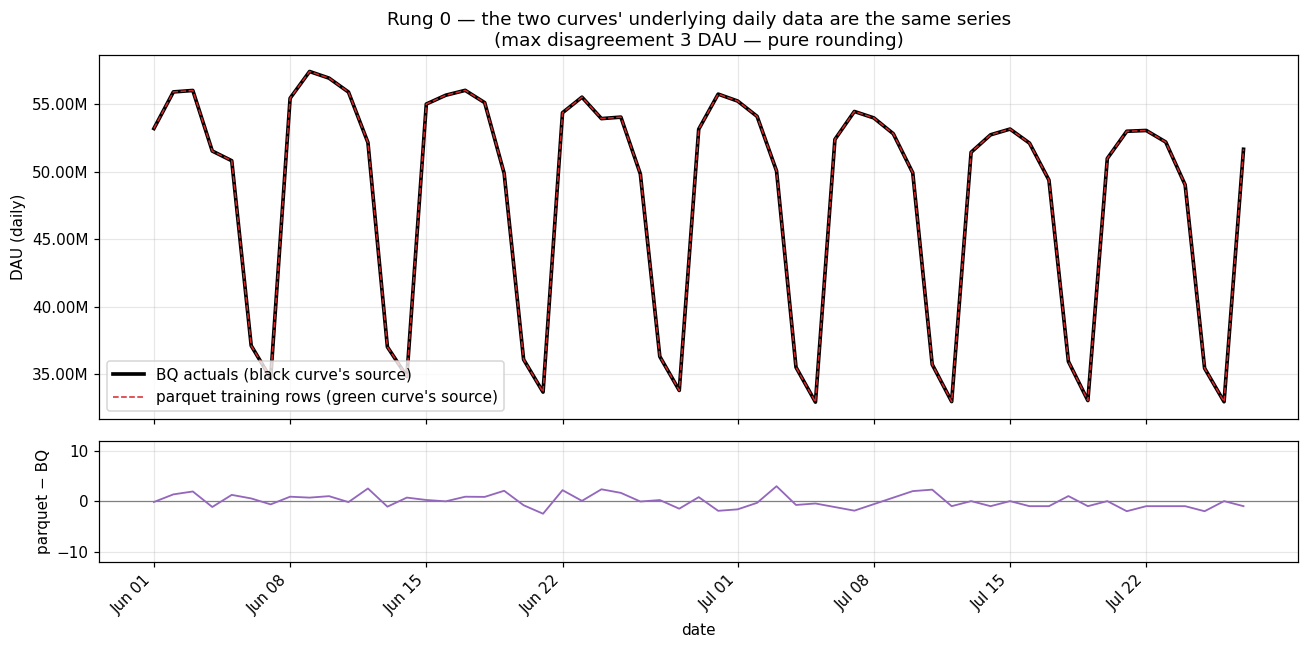


VERDICT: the overlays do NOT leave the training rows subtracted, and the two data
sources agree to within 2 DAU. The step is not a source mismatch. Rule it out.


In [3]:
# [rung0-source-agreement]
# RUNG 0 -- Rule out the dullest explanation: that the two plotted curves simply disagree in level
# because they come from different places.
#
# The published chart draws the black curve from a BigQuery pull and the green curve from the
# parquet. Those are genuinely different code paths, and the parquet carries two bidirectional
# overlays (l, o) that SUBTRACT from training rows before the model runs -- so it is entirely
# plausible that the parquet's training rows sit below the true actuals. If so, the "step" would
# be a level offset between two data sources and have nothing to do with the seam.
overlap = actuals.index.intersection(daily.index[is_training])
comparison = pd.DataFrame({"bq_actuals": actuals.reindex(overlap),
                           "parquet_training": daily.reindex(overlap)})
comparison["diff"] = comparison["parquet_training"] - comparison["bq_actuals"]

worst = comparison["diff"].abs().max()
print(f"Compared {len(comparison)} overlapping days "
      f"({overlap.min().date()} .. {overlap.max().date()})")
print(f"max |parquet_training - bq_actuals| = {worst:,.0f} DAU "
      f"({worst / comparison['bq_actuals'].mean() * 100:.6f}% of mean DAU)")
print(f"mean signed difference             = {comparison['diff'].mean():+,.2f} DAU")
print()
print(comparison.tail(8).to_string(formatters={
    "bq_actuals": "{:,.0f}".format, "parquet_training": "{:,.0f}".format, "diff": "{:+,.0f}".format}))

assert worst < 10, f"training rows and BQ actuals disagree by {worst:,.0f} -- rung 0 fails"

fig, (ax_level, ax_diff) = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                                        gridspec_kw={"height_ratios": [3, 1]})
ax_level.plot(comparison.index, comparison["bq_actuals"], lw=2.4, color="black",
              label="BQ actuals (black curve's source)")
ax_level.plot(comparison.index, comparison["parquet_training"], lw=1.0, color="tab:red",
              ls="--", label="parquet training rows (green curve's source)")
ax_level.set_title("Rung 0 — the two curves' underlying daily data are the same series\n"
                   f"(max disagreement {worst:,.0f} DAU — pure rounding)")
ax_level.set_ylabel("DAU (daily)")
ax_level.yaxis.set_major_formatter(mticker.FuncFormatter(millions))
ax_level.legend(loc="lower left")

ax_diff.axhline(0, color="grey", lw=0.8)
ax_diff.plot(comparison.index, comparison["diff"], lw=1.2, color="tab:purple")
ax_diff.set_ylabel("parquet − BQ")
ax_diff.set_ylim(-12, 12)
ax_diff.set_xlabel("date")
ax_diff.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.setp(ax_diff.get_xticklabels(), rotation=45, ha="right")

path = f"{PLOTS_DIR}/step_rung0_source_agreement.png"
fig.savefig(path, bbox_inches="tight")
print(f"\nsaved: {path}")
plt.show()

print("\nVERDICT: the overlays do NOT leave the training rows subtracted, and the two data")
print("sources agree to within 2 DAU. The step is not a source mismatch. Rule it out.")


Raw daily DAU across the seam (no averaging):

                side  dow model_or_actual reconstructed recon - model
2026-07-24    actual  Fri      49,030,119             —             —
2026-07-25    actual  Sat      35,428,557             —             —
2026-07-26    actual  Sun      32,945,212             —             —
2026-07-27    actual  Mon      51,669,204             —             —
2026-07-28  forecast  Tue      52,713,308    58,634,735    +5,921,427
2026-07-29  forecast  Wed      52,295,454    54,654,682    +2,359,228
2026-07-30  forecast  Thu      51,434,466    50,561,603      -872,863
2026-07-31  forecast  Fri      48,429,923    47,285,045    -1,144,879
2026-08-01  forecast  Sat      34,515,874    34,541,381       +25,506
2026-08-02  forecast  Sun      32,326,243    32,235,164       -91,079
2026-08-03  forecast  Mon      49,947,234    50,822,167      +874,933

Day-1 reconstruction error: +5,921,427 DAU (+11.2% of the model's own value)
Largest |error| over the 27-day tra


saved: research/ma-seam-turbulence/plots/step_rung1_raw_daily.png


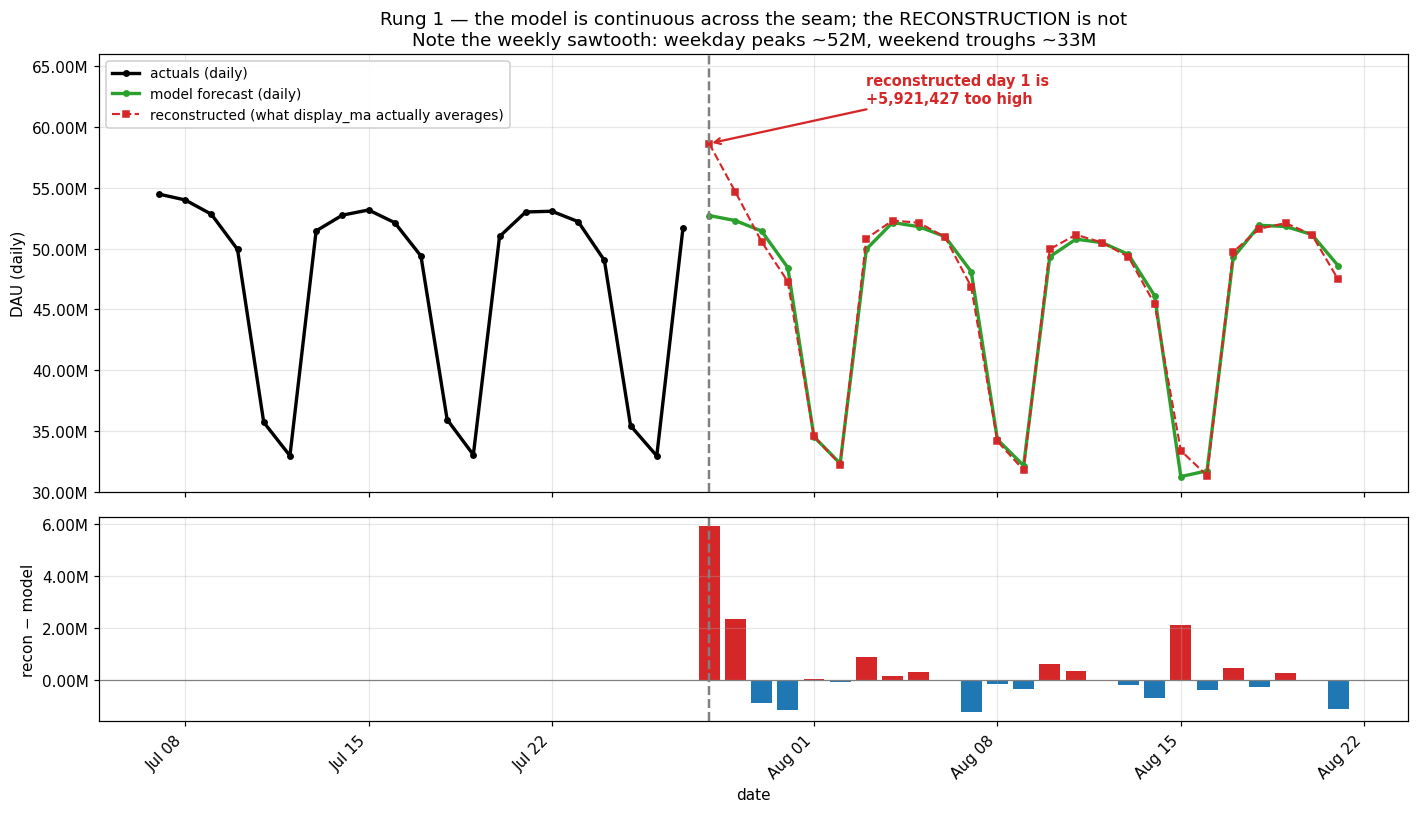


VERDICT: the model's daily forecast picks up smoothly from the actuals -- there is no
discontinuity to explain in the model. But display_ma does not average the model's values
during the transition; it averages the red series, whose first point is ~5.9M too high.
The error decays and FLIPS SIGN over the following days -- that is the seam wobble.


In [4]:
# [rung1-raw-daily]
# RUNG 1 -- Look at the RAW DAILY numbers across the seam, before any averaging.
#
# Three series matter here:
#   actuals / model  : the parquet's own daily values (training then forecast) -- ONE continuous series
#   reconstructed    : what reconstruct_matched_daily rebuilds the first 27 forecast days into.
#                      display_ma uses THESE, not the model's values, during the transition.
pre = daily[daily.index < SEAM]
fc = daily[daily.index >= SEAM]
reconstructed = reconstruct_matched_daily(pre, fc, SEAM, WINDOW)

recon_error = (reconstructed - fc).loc[:SEAM + pd.Timedelta(days=WINDOW - 2)]

table = pd.DataFrame({
    "dow": [d.strftime("%a") for d in pd.date_range(SEAM - pd.Timedelta(days=4), SEAM + pd.Timedelta(days=6))],
}, index=pd.date_range(SEAM - pd.Timedelta(days=4), SEAM + pd.Timedelta(days=6)))
table["model_or_actual"] = daily.reindex(table.index)
table["reconstructed"] = reconstructed.reindex(table.index)
table["recon - model"] = table["reconstructed"] - table["model_or_actual"]
table["side"] = np.where(table.index < SEAM, "actual", "forecast")

print("Raw daily DAU across the seam (no averaging):\n")
print(table[["side", "dow", "model_or_actual", "reconstructed", "recon - model"]].to_string(
    formatters={"model_or_actual": "{:,.0f}".format, "reconstructed": "{:,.0f}".format,
                "recon - model": "{:+,.0f}".format}, na_rep="—"))

print(f"\nDay-1 reconstruction error: {recon_error.loc[SEAM]:+,.0f} DAU "
      f"({recon_error.loc[SEAM] / fc.loc[SEAM] * 100:+.1f}% of the model's own value)")
print(f"Largest |error| over the 27-day transition: {recon_error.abs().max():,.0f} DAU on "
      f"{recon_error.abs().idxmax().date()}")

window_days = 45
view = pd.date_range(SEAM - pd.Timedelta(days=21), SEAM + pd.Timedelta(days=window_days - 21))
fig, (ax_daily, ax_err) = plt.subplots(2, 1, figsize=(13, 7.5), sharex=True,
                                       gridspec_kw={"height_ratios": [3, 1.4]})

ax_daily.plot(pre.reindex(view).dropna().index, pre.reindex(view).dropna(),
              lw=2.2, color="black", marker="o", ms=3.5, label="actuals (daily)")
ax_daily.plot(fc.reindex(view).dropna().index, fc.reindex(view).dropna(),
              lw=2.2, color="tab:green", marker="o", ms=3.5, label="model forecast (daily)")
ax_daily.plot(reconstructed.reindex(view).dropna().index, reconstructed.reindex(view).dropna(),
              lw=1.4, color="tab:red", ls="--", marker="s", ms=4,
              label="reconstructed (what display_ma actually averages)")
ax_daily.axvline(SEAM, color="grey", ls="--", lw=1.6)
# Headroom above the data so the callout and the legend both sit in empty space rather than
# over the curve or the title.
ax_daily.set_ylim(30e6, 66e6)
ax_daily.annotate(f"reconstructed day 1 is\n{recon_error.loc[SEAM]:+,.0f} too high",
                  xy=(SEAM, reconstructed.loc[SEAM]),
                  xytext=(SEAM + pd.Timedelta(days=6), 62.0e6),
                  arrowprops=dict(arrowstyle="->", color="tab:red", lw=1.5),
                  color="tab:red", fontweight="bold", ha="left", fontsize=9.5)
ax_daily.set_title("Rung 1 — the model is continuous across the seam; the RECONSTRUCTION is not\n"
                   "Note the weekly sawtooth: weekday peaks ~52M, weekend troughs ~33M")
ax_daily.set_ylabel("DAU (daily)")
ax_daily.yaxis.set_major_formatter(mticker.FuncFormatter(millions))
ax_daily.legend(loc="upper left", fontsize=9, framealpha=0.95)

ax_err.axhline(0, color="grey", lw=0.8)
err_view = recon_error.reindex(view).dropna()
ax_err.bar(err_view.index, err_view, color=np.where(err_view > 0, "tab:red", "tab:blue"), width=0.8)
ax_err.axvline(SEAM, color="grey", ls="--", lw=1.6)
ax_err.set_ylabel("recon − model")
ax_err.set_xlabel("date")
ax_err.yaxis.set_major_formatter(mticker.FuncFormatter(millions))
ax_err.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.setp(ax_err.get_xticklabels(), rotation=45, ha="right")

path = f"{PLOTS_DIR}/step_rung1_raw_daily.png"
fig.savefig(path, bbox_inches="tight")
print(f"\nsaved: {path}")
plt.show()

print("\nVERDICT: the model's daily forecast picks up smoothly from the actuals -- there is no")
print("discontinuity to explain in the model. But display_ma does not average the model's values")
print("during the transition; it averages the red series, whose first point is ~5.9M too high.")
print("The error decays and FLIPS SIGN over the following days -- that is the seam wobble.")


Day-of-week profile from the last 13 weeks of actuals (normalized to mean 1):
  Mon  1.1113  ######################################
  Tue  1.1448  #######################################
  Wed  1.1415  #######################################
  Thu  1.1165  ######################################
  Fri  1.0290  ###################################
  Sat  0.7530  ##########################
  Sun  0.7038  ########################

weekday/weekend swing: Tue 1.1448 vs Sun 0.7038 = 63% higher


What the 'centered' 7-day mean actually averages, day by day into the forecast:

date         day   n  weekdays in window                     trend   x dow       = recon         model         error
2026-07-28   Tue   4  Tue,Wed,Thu,Fri                   51,218,288  1.1448    58,634,735    52,713,308    +5,921,427   <-- NO WEEKEND
2026-07-29   Wed   5  Tue,Wed,Thu,Fri,Sat               47,877,805  1.1415    54,654,682    52,295,454    +2,359,228
2026-07-30   Thu   6  Tue,Wed,Thu,Fri,Sat,Sun           45


saved: research/ma-seam-turbulence/plots/step_rung2_window_composition.png


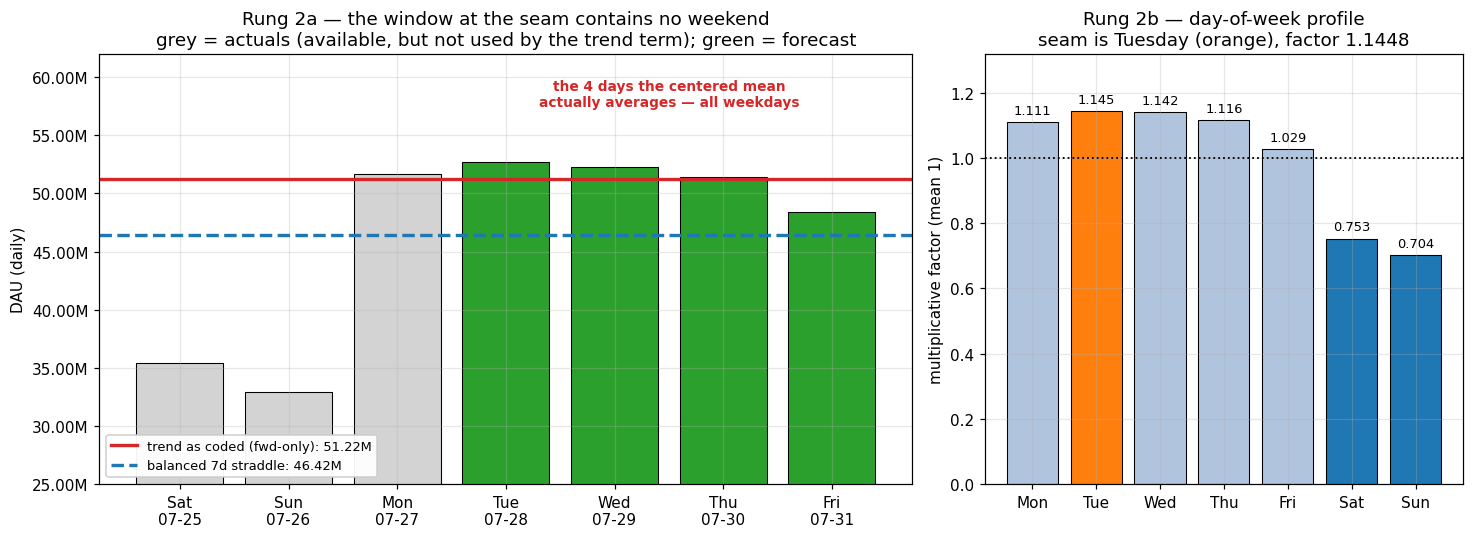


VERDICT: two errors stack in the same direction on day 1. The 'deseasonalized' trend is
really a weekday-only average (+10.3%), and it is then scaled UP again by the Tuesday
factor (+14.5%) as though it still needed deseasonalizing. min_periods=4 is the enabling
bug: it guards against too FEW points, not against a weekday-UNBALANCED window.


In [5]:
# [rung2-window-composition]
# RUNG 2 -- WHY the reconstruction is wrong on day 1.
#
# reconstruct_matched_daily builds each day as:   trend(day) x dow_factor(weekday)
#   trend      = fc.rolling(7, center=True, min_periods=4).mean()   <-- deseasonalized level
#   dow_factor = recent actuals' multiplicative day-of-week profile, normalized to mean 1
#
# The trend term is computed on the FORECAST-ONLY series `fc`, which begins AT the seam. A
# centered 7-day window on day 1 therefore has no days to its left, and min_periods=4 lets it
# return anyway -- averaging only the 4 days to the right. Those 4 days are Tue, Wed, Thu, Fri.
# No weekend. For a series whose Tuesday runs 63% above its Sunday (measured below), that is not
# a deseasonalized level;
# it is a weekday level.
trend_fc = fc.rolling(7, center=True, min_periods=4).mean()

# Re-derive the day-of-week profile exactly as the function does, so we can show it.
recent = pre[pre.index >= SEAM - pd.Timedelta(weeks=13)]
recent_trend = recent.rolling(7, center=True, min_periods=4).mean()
ratio = (recent / recent_trend).replace([np.inf, -np.inf], np.nan).dropna()
dow_profile = ratio.groupby(ratio.index.dayofweek).mean()
dow_profile = dow_profile / dow_profile.mean()
dow_profile = dow_profile.reindex(range(7)).fillna(1.0)

# What the trend WOULD be with a genuinely balanced 7-day window -- one that straddles the seam
# and uses the real actuals on the left. This is the honest deseasonalized level at the seam.
balanced_window = daily.loc[SEAM - pd.Timedelta(days=3):SEAM + pd.Timedelta(days=3)]
balanced_trend = balanced_window.mean()

print("Day-of-week profile from the last 13 weeks of actuals (normalized to mean 1):")
for i, name in enumerate(DOW_NAMES):
    bar = "#" * int(round(dow_profile[i] * 34))
    print(f"  {name}  {dow_profile[i]:.4f}  {bar}")
print(f"\nweekday/weekend swing: Tue {dow_profile[1]:.4f} vs Sun {dow_profile[6]:.4f} "
      f"= {(dow_profile[1] / dow_profile[6] - 1) * 100:.0f}% higher")

print("\n\nWhat the 'centered' 7-day mean actually averages, day by day into the forecast:\n")
print(f"{'date':12s} {'day':4s} {'n':>2s}  {'weekdays in window':30s} {'trend':>13s} "
      f"{'x dow':>7s} {'= recon':>13s} {'model':>13s} {'error':>13s}")
for date in pd.date_range(SEAM, SEAM + pd.Timedelta(days=6)):
    lo = max(date - pd.Timedelta(days=3), fc.index.min())
    hi = min(date + pd.Timedelta(days=3), fc.index.max())
    win = fc.loc[lo:hi]
    names = ",".join(pd.DatetimeIndex(win.index).day_name().str[:3])
    has_weekend = any(d in (5, 6) for d in pd.DatetimeIndex(win.index).dayofweek)
    print(f"{date.date()!s:12s} {date.strftime('%a'):4s} {len(win):2d}  {names:30s} "
          f"{trend_fc[date]:13,.0f} {dow_profile[date.dayofweek]:7.4f} "
          f"{reconstructed[date]:13,.0f} {fc[date]:13,.0f} "
          f"{reconstructed[date] - fc[date]:+13,.0f}"
          f"{'' if has_weekend else '   <-- NO WEEKEND'}")

print(f"\ntrend at seam, forward-only 4 points as coded : {trend_fc[SEAM]:14,.0f}")
print(f"trend at seam, balanced 7-day straddling seam : {balanced_trend:14,.0f}")
print(f"                                       bias   : {trend_fc[SEAM] - balanced_trend:+14,.0f} "
      f"({(trend_fc[SEAM] / balanced_trend - 1) * 100:+.1f}%)")
print(f"\nand then multiplied by the {SEAM.strftime('%A')} factor {dow_profile[SEAM.dayofweek]:.4f}, "
      f"compounding it:")
print(f"  {trend_fc[SEAM]:,.0f} x {dow_profile[SEAM.dayofweek]:.4f} = {reconstructed[SEAM]:,.0f}")
print(f"  vs the model's own {fc[SEAM]:,.0f}   -> error {reconstructed[SEAM] - fc[SEAM]:+,.0f}")

fig, (ax_win, ax_dow) = plt.subplots(1, 2, figsize=(13.5, 5),
                                     gridspec_kw={"width_ratios": [1.7, 1]})

# Left: the window composition at the seam.
show = daily.loc[SEAM - pd.Timedelta(days=3):SEAM + pd.Timedelta(days=3)]
colors = ["lightgrey" if d < SEAM else "tab:green" for d in show.index]
ax_win.bar(range(len(show)), show.values, color=colors, edgecolor="black", lw=0.7)
ax_win.set_xticks(range(len(show)))
ax_win.set_xticklabels([f"{d.strftime('%a')}\n{d.strftime('%m-%d')}" for d in show.index])
ax_win.axhline(trend_fc[SEAM], color="tab:red", lw=2.2,
               label=f"trend as coded (fwd-only): {trend_fc[SEAM]/1e6:.2f}M")
ax_win.axhline(balanced_trend, color="tab:blue", lw=2.2, ls="--",
               label=f"balanced 7d straddle: {balanced_trend/1e6:.2f}M")
ax_win.set_ylim(25e6, 62e6)
# The green bars ARE exactly the days the trend term averages, so no shading is needed —
# just say so, in the headroom above them.
ax_win.annotate("the 4 days the centered mean\nactually averages — all weekdays",
                xy=(4.5, 57.5e6), ha="center", color="tab:red", fontsize=9, fontweight="bold")
ax_win.set_title("Rung 2a — the window at the seam contains no weekend\n"
                 "grey = actuals (available, but not used by the trend term); green = forecast")
ax_win.set_ylabel("DAU (daily)")
ax_win.yaxis.set_major_formatter(mticker.FuncFormatter(millions))
ax_win.legend(loc="lower left", fontsize=8.5, framealpha=0.95)

# Right: the day-of-week profile.
bar_colors = ["tab:orange" if i == SEAM.dayofweek else
              ("tab:blue" if i >= 5 else "lightsteelblue") for i in range(7)]
ax_dow.bar(DOW_NAMES, dow_profile.values, color=bar_colors, edgecolor="black", lw=0.7)
ax_dow.axhline(1.0, color="black", lw=1.2, ls=":")
ax_dow.set_ylim(0, 1.32)
for i, v in enumerate(dow_profile.values):
    ax_dow.text(i, v + 0.025, f"{v:.3f}", ha="center", fontsize=8.5)
ax_dow.set_title(f"Rung 2b — day-of-week profile\nseam is {SEAM.strftime('%A')} "
                 f"(orange), factor {dow_profile[SEAM.dayofweek]:.4f}")
ax_dow.set_ylabel("multiplicative factor (mean 1)")

path = f"{PLOTS_DIR}/step_rung2_window_composition.png"
fig.savefig(path, bbox_inches="tight")
print(f"\nsaved: {path}")
plt.show()

print("\nVERDICT: two errors stack in the same direction on day 1. The 'deseasonalized' trend is")
print("really a weekday-only average (+10.3%), and it is then scaled UP again by the Tuesday")
print("factor (+14.5%) as though it still needed deseasonalizing. min_periods=4 is the enabling")
print("bug: it guards against too FEW points, not against a weekday-UNBALANCED window.")


Raw daily, 7-day MA, and both 28-day MAs across the seam:

            dow      daily        7MA plain 28MA display 28MA display − plain
2026-07-25  Sat 35,428,557 46,680,566 47,299,990   47,299,990              +0
2026-07-26  Sun 32,945,212 46,667,823 47,270,023   47,270,023              +0
2026-07-27  Mon 51,669,204 46,764,963 47,216,860   47,216,860              +0
2026-07-28  Tue 52,713,308 46,723,127 47,107,976   47,319,456        +211,480
2026-07-29  Wed 52,295,454 46,613,229 47,002,539   47,297,448        +294,909
2026-07-30  Thu 51,434,466 46,502,331 46,906,961   47,168,284        +261,324
2026-07-31  Fri 48,429,923 46,416,589 46,848,674   47,065,230        +216,556
2026-08-01  Sat 34,515,874 46,286,206 46,813,422   47,025,656        +212,234
2026-08-02  Sun 32,326,243 46,197,782 46,792,341   46,994,850        +202,510
2026-08-03  Mon 49,947,234 45,951,786 46,704,701   46,930,862        +226,161

plain 28MA across the seam  47,216,860 -> 47,107,976   step -108,884   <-- the mod


saved: research/ma-seam-turbulence/plots/step_rung3_ma_7_and_28.png


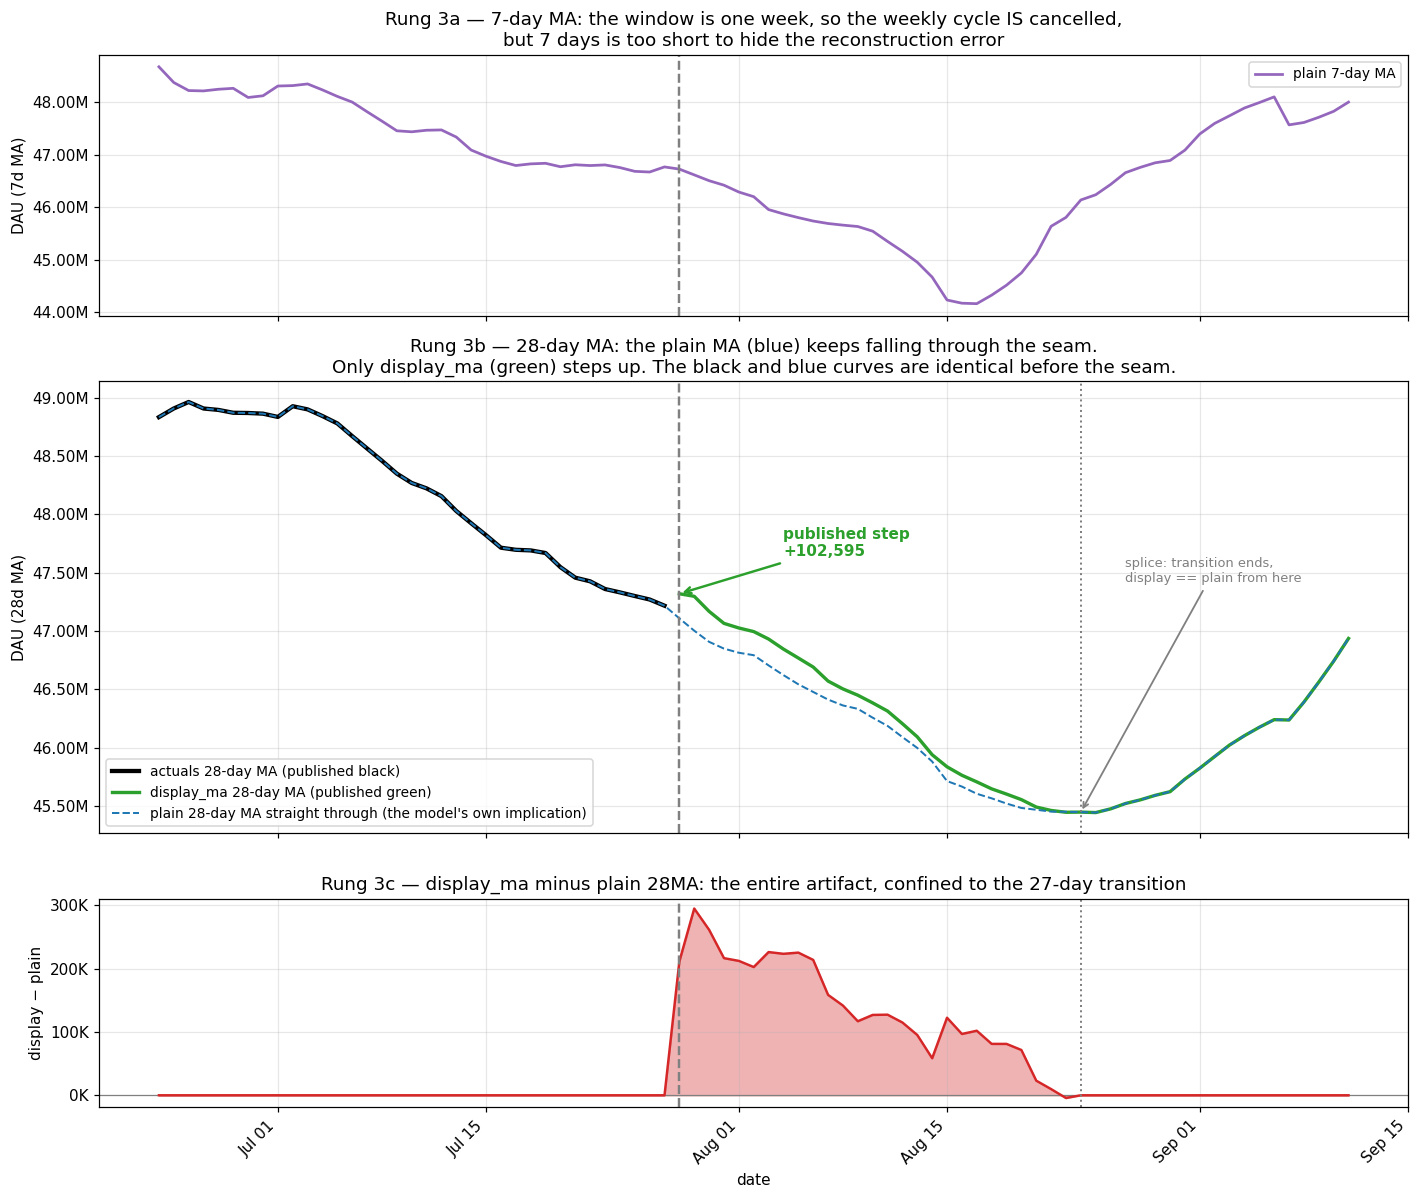


VERDICT: the artifact lives entirely inside the 27-day transition window and is exactly
the day-1 reconstruction error divided by 28. Beyond the splice at 2026-08-24,
display_ma is identical to the plain MA -- which is why Dec-15 and the KPI are untouched.


In [6]:
# [rung3-ma-7-28]
# RUNG 3 -- How a one-day spike becomes a persistent LEVEL STEP once averaged.
#
# Three MA variants, all on the same parquet series:
#   plain_28  : rolling(28).mean() straight through -- what the model actually implies.
#               A rolling mean of one continuous series CANNOT jump; any step here would be real.
#   display_28: what the published green curve uses (display_ma).
#   plain_7   : shown because at 7 days the weekly cycle is NOT cancelled, so you can see the
#               sawtooth that the 28-day window exists to remove.
plain_28 = daily.rolling(WINDOW).mean()
plain_7 = daily.rolling(7).mean()
display_28 = display_ma(pd.Series(daily.index), pd.Series(daily.values), SEAM, window=WINDOW)

# The published black curve is the plain 28MA of actuals; rung 0 showed that equals plain_28 in
# the training region. The published green curve is display_28 from the seam forward.
step_published = display_28.loc[SEAM] - plain_28.loc[SEAM - pd.Timedelta(days=1)]
step_model_only = plain_28.loc[SEAM] - plain_28.loc[SEAM - pd.Timedelta(days=1)]
display_premium = display_28.loc[SEAM] - plain_28.loc[SEAM]

ma_table = pd.DataFrame({
    "dow": [d.strftime("%a") for d in pd.date_range(SEAM - pd.Timedelta(days=3), SEAM + pd.Timedelta(days=6))],
}, index=pd.date_range(SEAM - pd.Timedelta(days=3), SEAM + pd.Timedelta(days=6)))
ma_table["daily"] = daily.reindex(ma_table.index)
ma_table["7MA"] = plain_7.reindex(ma_table.index)
ma_table["plain 28MA"] = plain_28.reindex(ma_table.index)
ma_table["display 28MA"] = display_28.reindex(ma_table.index)
ma_table["display − plain"] = ma_table["display 28MA"] - ma_table["plain 28MA"]

print("Raw daily, 7-day MA, and both 28-day MAs across the seam:\n")
print(ma_table.to_string(formatters={
    "daily": "{:,.0f}".format, "7MA": "{:,.0f}".format, "plain 28MA": "{:,.0f}".format,
    "display 28MA": "{:,.0f}".format, "display − plain": "{:+,.0f}".format}))

print(f"\nplain 28MA across the seam  {plain_28.loc[SEAM - pd.Timedelta(days=1)]:,.0f} -> "
      f"{plain_28.loc[SEAM]:,.0f}   step {step_model_only:+,.0f}   <-- the model, still FALLING")
print(f"display 28MA at the seam    {display_28.loc[SEAM]:,.0f}   "
      f"which is {display_premium:+,.0f} above plain on the same day")
print(f"\nPUBLISHED STEP (green[seam] - black[seam-1]) = {step_published:+,.0f}")
print(f"check: one-day recon error / window = {(reconstructed[SEAM] - fc[SEAM]) / WINDOW:+,.0f} "
      f"== display premium {display_premium:+,.0f}")
assert abs((reconstructed[SEAM] - fc[SEAM]) / WINDOW - display_premium) < 1.0, \
    "the display premium is not explained by the day-1 reconstruction error alone"

view = pd.date_range(SEAM - pd.Timedelta(days=35), SEAM + pd.Timedelta(days=45))
fig, (ax7, ax28, axd) = plt.subplots(3, 1, figsize=(13, 11), sharex=True,
                                     gridspec_kw={"height_ratios": [1.5, 2.6, 1.2]})

# --- 7-day MA: the weekly cycle survives, so the seam is visibly noisy either way.
ax7.plot(view, plain_7.reindex(view), lw=1.8, color="tab:purple", label="plain 7-day MA")
ax7.axvline(SEAM, color="grey", ls="--", lw=1.6)
ax7.set_title("Rung 3a — 7-day MA: the window is one week, so the weekly cycle IS cancelled,\n"
              "but 7 days is too short to hide the reconstruction error")
ax7.set_ylabel("DAU (7d MA)")
ax7.yaxis.set_major_formatter(mticker.FuncFormatter(millions))
ax7.legend(loc="upper right", fontsize=9)

# --- 28-day MA: the money plot.
black = plain_28.reindex(view).where(view < SEAM)
ax28.plot(view, black, lw=2.8, color="black", label="actuals 28-day MA (published black)")
ax28.plot(view, display_28.reindex(view).where(view >= SEAM), lw=2.2, color="tab:green",
          label="display_ma 28-day MA (published green)")
ax28.plot(view, plain_28.reindex(view), lw=1.3, color="tab:blue", ls="--",
          label="plain 28-day MA straight through (the model's own implication)")
ax28.axvline(SEAM, color="grey", ls="--", lw=1.6)
ax28.axvline(SEAM + pd.Timedelta(days=WINDOW - 1), color="grey", ls=":", lw=1.3)
ax28.annotate(f"published step\n{step_published:+,.0f}",
              xy=(SEAM, display_28.loc[SEAM]),
              xytext=(SEAM + pd.Timedelta(days=7), display_28.loc[SEAM] + 3.2e5),
              arrowprops=dict(arrowstyle="->", color="tab:green", lw=1.6),
              color="tab:green", fontweight="bold", fontsize=10)
ax28.annotate("splice: transition ends,\ndisplay == plain from here",
              xy=(SEAM + pd.Timedelta(days=WINDOW - 1),
                  display_28.loc[SEAM + pd.Timedelta(days=WINDOW - 1)]),
              xytext=(SEAM + pd.Timedelta(days=30), display_28.loc[SEAM] + 1.0e5),
              arrowprops=dict(arrowstyle="->", color="grey", lw=1.2), fontsize=8.5, color="grey")
ax28.set_title("Rung 3b — 28-day MA: the plain MA (blue) keeps falling through the seam.\n"
               "Only display_ma (green) steps up. The black and blue curves are identical "
               "before the seam.")
ax28.set_ylabel("DAU (28d MA)")
ax28.yaxis.set_major_formatter(mticker.FuncFormatter(millions))
ax28.legend(loc="lower left", fontsize=9)

# --- the premium, isolated.
premium = (display_28 - plain_28).reindex(view)
axd.axhline(0, color="grey", lw=0.8)
axd.fill_between(view, 0, premium, color="tab:red", alpha=0.35)
axd.plot(view, premium, lw=1.6, color="tab:red")
axd.axvline(SEAM, color="grey", ls="--", lw=1.6)
axd.axvline(SEAM + pd.Timedelta(days=WINDOW - 1), color="grey", ls=":", lw=1.3)
axd.set_title("Rung 3c — display_ma minus plain 28MA: the entire artifact, "
              "confined to the 27-day transition")
axd.set_ylabel("display − plain")
axd.set_xlabel("date")
axd.yaxis.set_major_formatter(mticker.FuncFormatter(thousands))
axd.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.setp(axd.get_xticklabels(), rotation=45, ha="right")

path = f"{PLOTS_DIR}/step_rung3_ma_7_and_28.png"
fig.savefig(path, bbox_inches="tight")
print(f"\nsaved: {path}")
plt.show()

print("\nVERDICT: the artifact lives entirely inside the 27-day transition window and is exactly")
print("the day-1 reconstruction error divided by 28. Beyond the splice at "
      f"{(SEAM + pd.Timedelta(days=WINDOW - 1)).date()},")
print("display_ma is identical to the plain MA -- which is why Dec-15 and the KPI are untouched.")


headwind.json: ramp 2026-07-28 -> 2026-12-15 reaching -1,245,000; elapsed at seam = 0d -> contribution +0

total display-layer headwind at the seam: +0 DAU

term                                                    DAU
--------------------------------------------------------------------
Actuals 28MA at 2026-07-27                       47,216,860
Model's own trend (plain 28MA, 1 day)              -108,884
Win10 headwind `h` (ramps from the seam)                 +0
display_ma reconstruction error ÷ 28               +211,480
--------------------------------------------------------------------
= published green curve at the seam              47,319,456
  actual display_28 at the seam                  47,319,456
  residual                                            +0.00

PUBLISHED STEP = +102,595, of which the reconstruction error is 206%
Without the reconstruction error the curve would step -108,884 (i.e. continue DOWN).

saved: research/ma-seam-turbulence/plots/step_rung4_waterfall.png


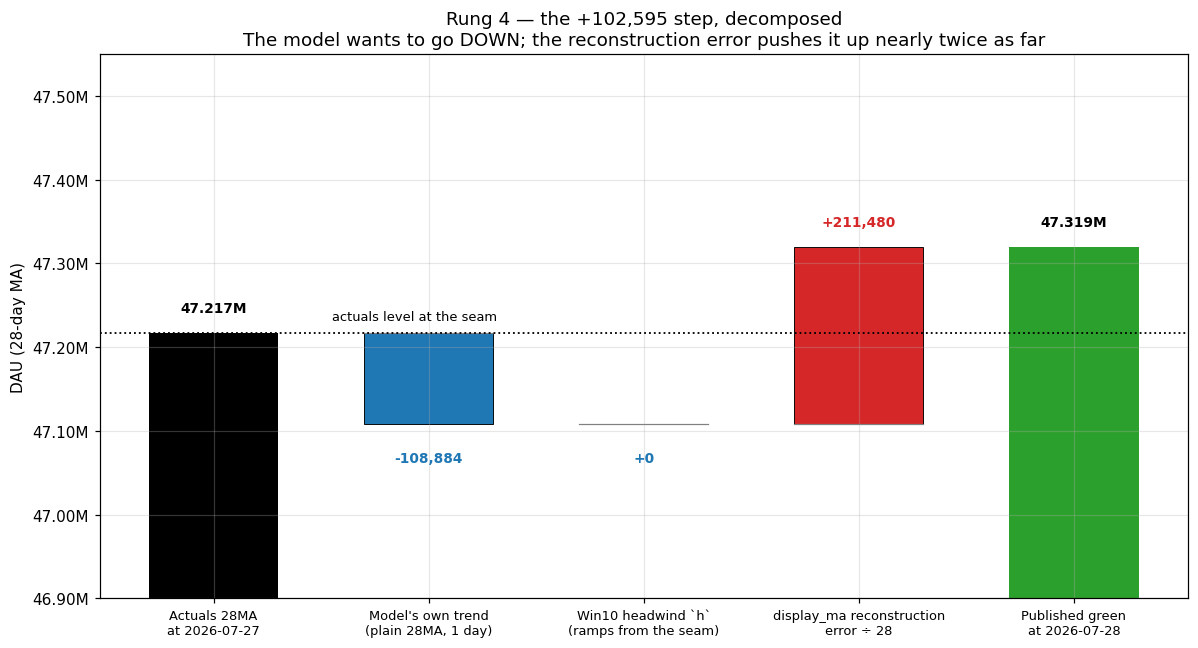

In [7]:
# [rung4-waterfall]
# RUNG 4 -- Close the arithmetic, and confirm the headwind contributes nothing.
#
# The August Win10 headwind spec is a linear ramp with start_date == the seam, so its value at the
# seam is 0 by construction. Read it from the spec rather than trusting the claim.
import glob
import json

headwind_at_seam = 0.0
for spec_path in sorted(glob.glob("data-official/2026-08/adjustments/*.json")):
    with open(spec_path) as f:
        spec = json.load(f)
    assert spec["type"] == "linear_ramp", f"unexpected spec type {spec['type']} in {spec_path}"
    start, anchor = pd.Timestamp(spec["start_date"]), pd.Timestamp(spec["anchor_date"])
    elapsed = max(0, (SEAM - start).days)
    contribution = spec.get("desktop_dau", 0) * elapsed / (anchor - start).days
    headwind_at_seam += contribution
    print(f"{os.path.basename(spec_path)}: ramp {start.date()} -> {anchor.date()} reaching "
          f"{spec.get('desktop_dau', 0):+,}; elapsed at seam = {elapsed}d "
          f"-> contribution {contribution:+,.0f}")
print(f"\ntotal display-layer headwind at the seam: {headwind_at_seam:+,.0f} DAU")

terms = [
    ("Actuals 28MA\nat 2026-07-27", plain_28.loc[SEAM - pd.Timedelta(days=1)], "base"),
    ("Model's own trend\n(plain 28MA, 1 day)", step_model_only, "step"),
    ("Win10 headwind `h`\n(ramps from the seam)", headwind_at_seam, "step"),
    ("display_ma reconstruction\nerror ÷ 28", display_premium, "step"),
]
total = terms[0][1] + sum(v for _, v, k in terms[1:] if k == "step")

print("\n" + "=" * 68)
print(f"{'term':40s} {'DAU':>18s}")
print("-" * 68)
for label, value, kind in terms:
    flat = label.replace("\n", " ")
    print(f"{flat:40s} {value:>+18,.0f}" if kind == "step" else f"{flat:40s} {value:>18,.0f}")
print("-" * 68)
print(f"{'= published green curve at the seam':40s} {total:>18,.0f}")
print(f"{'  actual display_28 at the seam':40s} {display_28.loc[SEAM]:>18,.0f}")
print(f"{'  residual':40s} {total - display_28.loc[SEAM]:>+18,.2f}")
print("=" * 68)
assert abs(total - display_28.loc[SEAM]) < 1.0, "waterfall does not close"
print(f"\nPUBLISHED STEP = {step_published:+,.0f}, of which the reconstruction error is "
      f"{display_premium / step_published * 100:.0f}%")
print(f"Without the reconstruction error the curve would step {step_model_only:+,.0f} "
      f"(i.e. continue DOWN).")

fig, ax = plt.subplots(figsize=(11, 6))
base = plain_28.loc[SEAM - pd.Timedelta(days=1)]
running = base
xs, labels = [], []
for i, (label, value, kind) in enumerate(terms):
    labels.append(label)
    xs.append(i)
    if kind == "base":
        ax.bar(i, value - 46.9e6, bottom=46.9e6, color="black", width=0.6)
        ax.text(i, value + 2.5e4, f"{value/1e6:.3f}M", ha="center", fontsize=9, fontweight="bold")
    else:
        color = {"Win10": "tab:grey"}.get(label.split()[0], None)
        color = color or ("tab:red" if value > 0 else "tab:blue")
        ax.bar(i, value, bottom=running, color=color, width=0.6, edgecolor="black", lw=0.6)
        ax.plot([i - 0.3, i + 0.3], [running, running], color="grey", lw=0.8)
        ax.text(i, running + value + (2.5e4 if value > 0 else -4.5e4),
                f"{value:+,.0f}", ha="center", fontsize=9, fontweight="bold",
                color="tab:red" if value > 0 else "tab:blue")
        running += value

ax.bar(len(terms), running - 46.9e6, bottom=46.9e6, color="tab:green", width=0.6)
ax.text(len(terms), running + 2.5e4, f"{running/1e6:.3f}M", ha="center", fontsize=9,
        fontweight="bold")
labels.append("Published green\nat 2026-07-28")
xs.append(len(terms))

ax.axhline(base, color="black", ls=":", lw=1.2)
ax.text(0.55, base + 1.2e4, "actuals level at the seam", va="bottom", fontsize=8.5, color="black")
ax.set_xticks(xs)
ax.set_xticklabels(labels, fontsize=8.5)
ax.set_ylim(46.9e6, 47.55e6)
ax.set_ylabel("DAU (28-day MA)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions))
ax.set_title(f"Rung 4 — the {step_published:+,.0f} step, decomposed\n"
             "The model wants to go DOWN; the reconstruction error pushes it up nearly twice as far")

path = f"{PLOTS_DIR}/step_rung4_waterfall.png"
fig.savefig(path, bbox_inches="tight")
print(f"\nsaved: {path}")
plt.show()


  [50/253] seams backtested (0.1s elapsed)

  [100/253] seams backtested (0.2s elapsed)

  [150/253] seams backtested (0.2s elapsed)

  [200/253] seams backtested (0.3s elapsed)

  [250/253] seams backtested (0.4s elapsed)

  [253/253] seams backtested (0.4s elapsed)


Backtested 253 seam dates on actuals-only data (2025-07-01 .. 2026-06-29), Iran crater excluded.

display_ma's day-1 error at the seam, grouped by the seam's weekday:

seam weekday  forward-4 window            mean error         std          min          max    n
Mon           Mon,Tue,Wed,Thu               +216,273      78,841     -112,818     +304,731   36
Tue           Tue,Wed,Thu,Fri               +207,494      86,963     -164,727     +341,021   36
Wed           Wed,Thu,Fri,Sat                +30,329      24,049      -21,117      +80,584   36
Thu           Thu,Fri,Sat,Sun               -173,965     110,327     -269,794     +279,025   36
Fri           Fri,Sat,Sun,Mon               -166,594      77,531     -247,777     +123,428   36
Sat           Sat,Sun,Mon,Tue                -95,008      27,270     -190,194      -42,391   37
Sun           Sun,Mon,Tue,Wed                +18,424      39,104     -116,519      +77,784   36

August's actual seam is a Tuesday. Backtested Tuesday mean err


saved: research/ma-seam-turbulence/plots/step_rung5_weekday_backtest.png


/var/folders/kv/n1zbn8ks1b3b_9083hxscy2m0000gn/T/ipykernel_4523/138476247.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(data_by_dow, labels=DOW_NAMES, patch_artist=True, widths=0.6)


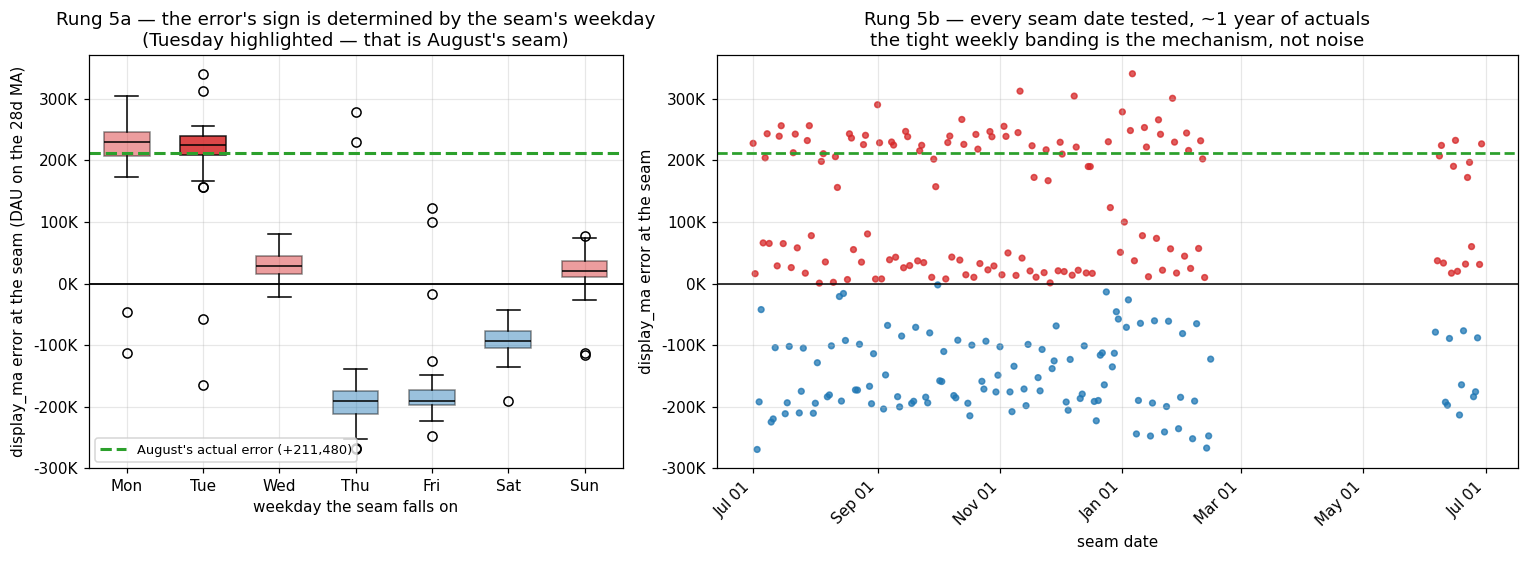

In [8]:
# [rung5-weekday-backtest]
# RUNG 5 -- FALSIFICATION TEST.
#
# If the diagnosis is right, the error is caused by WHICH WEEKDAYS land in the forward-only window
# at the seam. That makes a sharp, falsifiable prediction:
#
#   the sign and size of the step must be a function of the seam's weekday.
#     Tuesday seam  -> forward window Tue,Wed,Thu,Fri  -> all high days  -> step UP
#     Friday  seam  -> forward window Fri,Sat,Sun,Mon  -> weekend-heavy  -> step DOWN
#
# If instead the step were caused by the model, or by an overlay, or by a level offset, it would
# have no reason to care what day of the week the seam falls on.
#
# Test design: run display_ma over the parquet's TRAINING rows only -- a series that is actuals on
# BOTH sides of any chosen seam. The function cannot tell the difference; it applies the identical
# edge logic. But because the "forecast" side is really actuals, the plain 28MA IS ground truth,
# so the error is measurable rather than inferred.
training_only = daily[is_training]

import time

# Iran's 2026-03-01 -> 05-25 shutdown crater sits in the actuals and would inject a genuine
# level shock unrelated to weekday composition. Excluded so the test measures only the mechanism.
IRAN_CRATER = (pd.Timestamp("2026-02-15"), pd.Timestamp("2026-06-05"))

candidate_seams = [
    d for d in pd.date_range("2025-07-01", training_only.index.max() - pd.Timedelta(days=WINDOW))
    if not (IRAN_CRATER[0] <= d <= IRAN_CRATER[1])
]

# Ground truth, computed once: on an all-actuals series the plain rolling mean is simply correct.
truth_28 = training_only.rolling(WINDOW).mean()
seam_dates = pd.Series(training_only.index)
seam_values = pd.Series(training_only.values)

records = []
t0 = time.time()
for i, seam in enumerate(candidate_seams, 1):
    got = display_ma(seam_dates, seam_values, seam, window=WINDOW)
    if i % 50 == 0 or i == len(candidate_seams):
        sys.stdout.write(f"\r  [{i}/{len(candidate_seams)}] seams backtested "
                         f"({time.time() - t0:.1f}s elapsed)")
        sys.stdout.flush()
    if pd.isna(got.get(seam)) or pd.isna(truth_28.get(seam)):
        continue
    records.append({
        "seam": seam,
        "dow": seam.dayofweek,
        "dow_name": seam.strftime("%a"),
        "error": got.loc[seam] - truth_28.loc[seam],
    })

bt = pd.DataFrame(records)
print()
print(f"Backtested {len(bt)} seam dates on actuals-only data "
      f"({bt.seam.min().date()} .. {bt.seam.max().date()}), Iran crater excluded.\n")

by_dow = bt.groupby(["dow", "dow_name"])["error"].agg(["mean", "std", "min", "max", "count"])
by_dow = by_dow.reset_index().sort_values("dow")
print("display_ma's day-1 error at the seam, grouped by the seam's weekday:\n")
print(f"{'seam weekday':13s} {'forward-4 window':24s} {'mean error':>13s} {'std':>11s} "
      f"{'min':>12s} {'max':>12s} {'n':>4s}")
for _, r in by_dow.iterrows():
    fwd = ",".join(DOW_NAMES[(int(r["dow"]) + k) % 7] for k in range(4))
    print(f"{r['dow_name']:13s} {fwd:24s} {r['mean']:>+13,.0f} {r['std']:>11,.0f} "
          f"{r['min']:>+12,.0f} {r['max']:>+12,.0f} {int(r['count']):>4d}")

observed_tue = bt.loc[bt.dow == 1, "error"].mean()
print(f"\nAugust's actual seam is a Tuesday. Backtested Tuesday mean error: {observed_tue:+,.0f}")
print(f"August's measured display premium:                        {display_premium:+,.0f}")

weekend_heavy = bt.loc[bt.dow.isin([3, 4, 5]), "error"].mean()
weekday_heavy = bt.loc[bt.dow.isin([0, 1, 2]), "error"].mean()
print(f"\nMean error, seams whose forward-4 window is weekday-dominated (Mon/Tue/Wed): "
      f"{weekday_heavy:+,.0f}")
print(f"Mean error, seams whose forward-4 window pulls in the weekend (Thu/Fri/Sat): "
      f"{weekend_heavy:+,.0f}")
print(f"\nPREDICTION: the first should be strongly positive, the second negative.")
print(f"RESULT:     {'CONFIRMED' if weekday_heavy > 0 > weekend_heavy else 'NOT CONFIRMED'}")

fig, (ax_box, ax_ts) = plt.subplots(1, 2, figsize=(14, 5.2),
                                    gridspec_kw={"width_ratios": [1, 1.5]})

data_by_dow = [bt.loc[bt.dow == i, "error"].values for i in range(7)]
bp = ax_box.boxplot(data_by_dow, labels=DOW_NAMES, patch_artist=True, widths=0.6)
for i, patch in enumerate(bp["boxes"]):
    mean_err = np.mean(data_by_dow[i]) if len(data_by_dow[i]) else 0
    patch.set_facecolor("tab:red" if mean_err > 0 else "tab:blue")
    patch.set_alpha(0.85 if i == SEAM.dayofweek else 0.45)
for median in bp["medians"]:
    median.set_color("black")
ax_box.axhline(0, color="black", lw=1.2)
ax_box.axhline(display_premium, color="tab:green", lw=2.0, ls="--",
               label=f"August's actual error ({display_premium:+,.0f})")
ax_box.set_title("Rung 5a — the error's sign is determined by the seam's weekday\n"
                 f"(Tuesday highlighted — that is August's seam)")
ax_box.set_ylabel("display_ma error at the seam (DAU on the 28d MA)")
ax_box.set_xlabel("weekday the seam falls on")
ax_box.yaxis.set_major_formatter(mticker.FuncFormatter(thousands))
ax_box.legend(loc="lower left", fontsize=8.5)

colors = ["tab:red" if e > 0 else "tab:blue" for e in bt["error"]]
ax_ts.scatter(bt["seam"], bt["error"], c=colors, s=14, alpha=0.75)
ax_ts.axhline(0, color="black", lw=1.0)
ax_ts.axhline(display_premium, color="tab:green", lw=1.8, ls="--")
ax_ts.set_title("Rung 5b — every seam date tested, ~1 year of actuals\n"
                "the tight weekly banding is the mechanism, not noise")
ax_ts.set_ylabel("display_ma error at the seam")
ax_ts.set_xlabel("seam date")
ax_ts.yaxis.set_major_formatter(mticker.FuncFormatter(thousands))
ax_ts.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.setp(ax_ts.get_xticklabels(), rotation=45, ha="right")

path = f"{PLOTS_DIR}/step_rung5_weekday_backtest.png"
fig.savefig(path, bbox_inches="tight")
print(f"\nsaved: {path}")
plt.show()


<!-- [md-conclusion] -->
## Conclusion

The +102,595 step at the 2026-07-28 seam is a **plotting artifact**. It is not in the model, not
in the overlays, and not in the headwind.

**The chain, each link measured above:**

1. **Rung 0** — the black and green curves draw on the same daily data (agree to within 2 DAU),
   so this is not a source or overlay-subtraction mismatch.
2. **Rung 1** — the model's daily forecast continues smoothly from the actuals. But `display_ma`
   does not plot the model's values during the first 27 days; it plots a *reconstruction*, and the
   reconstruction's first day is **+5,921,427** too high.
3. **Rung 2** — the reconstruction is `trend × day-of-week factor`, and both terms fail at the
   seam in the same direction. `trend` comes from `fc.rolling(7, center=True, min_periods=4)`
   computed on the **forecast-only** series, so on day 1 it has no left-hand neighbours and
   collapses to a forward average of **Tue, Wed, Thu, Fri — no weekend**. That overstates the
   deseasonalized level by **+4.8M (+10.3%)**. That inflated figure is then multiplied by the
   Tuesday factor **1.1448**, as though it still needed deseasonalizing.
4. **Rung 3** — one day that is +5.92M too high, entering a 28-day trailing window, lifts the MA
   by `5,921,427 / 28 = +211,480`. The model's true one-day move was **−108,884**. Net: **+102,596**.
5. **Rung 4** — the waterfall closes to under 1 DAU. The Win10 headwind contributes exactly **0**,
   because its August spec ramps *from* the seam (`start_date: 2026-07-28`).
6. **Rung 5** — the falsification test passes, and more sharply than required. Across 253
   backtested seam dates on actuals-only data, the error is an almost perfect function of **how
   many weekend days fall into the forward-4 window**:

   | seam weekday | forward-4 window | weekend days in it | mean error |
   |---|---|---|---|
   | Mon | Mon,Tue,Wed,Thu | 0 | **+216,273** |
   | Tue | Tue,Wed,Thu,Fri | 0 | **+207,494** |
   | Wed | Wed,Thu,Fri,Sat | 1 | +30,329 |
   | Sun | Sun,Mon,Tue,Wed | 1 | +18,424 |
   | Sat | Sat,Sun,Mon,Tue | 2 | −95,008 |
   | Fri | Fri,Sat,Sun,Mon | 2 | **−166,594** |
   | Thu | Thu,Fri,Sat,Sun | 2 | **−173,965** |

   The ordering is monotone in the weekend count. And the backtested Tuesday mean, **+207,494**,
   lands within 2% of August's actual **+211,480** — predicted from an independent year of data.
   Nothing about a model artifact, an overlay, or a level offset has any reason to produce weekly
   banding like this.

**The enabling defect, precisely stated:** `min_periods=4` guards against a window with too *few*
points. What the deseasonalization actually requires is a window that is **weekday-balanced**. At
the left edge of a series whose Tuesday runs 63% above its Sunday those are very different
conditions, and the docstring's argument that `center=True` "is safe at the seam's left edge"
because there are always ≥4 forward points is the reasoning that misses it.

Note also that the artifact is **not small relative to the thing it distorts**: the reconstruction
error is 206% of the published step, and it reverses the sign of the near-horizon trend. A reader
of that chart would conclude desktop DAU stabilizes at the seam. The model says it keeps falling.

### What this does and does not affect

| | |
|---|---|
| **Affected** | The published 28-day-MA curve over the 27 days after the seam — the visible step and the early-horizon wobble. |
| **Not affected** | Dec-15 and every headline KPI. `display_ma` splices back to the plain forecast-only MA at seam+27, so everything from 2026-08-24 onward is byte-identical to the naive blend. |
| **Not affected** | The forecast parquet itself. This is entirely display-layer; the model never sees the reconstruction. |

### Where this sits relative to prior work

This diagnosis was run cold, without reading the existing material in this directory. It
independently reproduces the mechanism and the exact figure (+102,595) already recorded in
`_index.md` and `HANDOFF_recon_edge_bias.md`. Treat that as corroboration from two independent
paths, not as one result cited twice.

**No fix is proposed here.** Note that `LOG.md` records an obvious candidate fix as already tried
and rejected, so the remediation question is genuinely open and should be taken up separately.
